Week 17 · Day 6 — Comparing Generative Families
Why this matters

By now, you’ve built GANs, VAEs, and Diffusion Models — three core families of modern generative AI.
Each learns the data distribution in a different way.
Understanding their differences helps you choose the right tool for image synthesis, reconstruction, or creative control.

Theory Essentials
Model	Core Idea	Strengths	Weaknesses
GAN	Adversarial training (Generator vs Discriminator)	Sharp, realistic samples	Unstable training, mode collapse
VAE	Probabilistic encoding (μ, σ) + reconstruction	Smooth latent space, interpretable	Blurry outputs
Diffusion	Gradual denoising from noise	Stable, very high-quality images	Slow sampling, compute-heavy

GAN learns implicitly (no explicit probability).

VAE learns explicitly (models p(x|z)).

Diffusion learns a score function (∇log p(x)) by predicting noise.

Each balances trade-offs between fidelity, diversity, and controllability.

Training GAN...
[GAN] Epoch 1/8  D=1.022  G=1.186
[GAN] Epoch 2/8  D=1.656  G=0.595
[GAN] Epoch 3/8  D=0.921  G=0.950
[GAN] Epoch 4/8  D=0.613  G=2.334
[GAN] Epoch 5/8  D=1.145  G=2.609
[GAN] Epoch 6/8  D=0.742  G=1.762
[GAN] Epoch 7/8  D=0.616  G=2.173
[GAN] Epoch 8/8  D=1.007  G=1.472

Training VAE...
[VAE] Epoch 1/3  recon=0.1397  KL=20.9017
[VAE] Epoch 2/3  recon=0.1004  KL=23.4131
[VAE] Epoch 3/3  recon=0.0883  KL=25.6105

Training Denoiser...
[DAE] Epoch 1/3  mse=0.1104
[DAE] Epoch 2/3  mse=0.0789
[DAE] Epoch 3/3  mse=0.0602


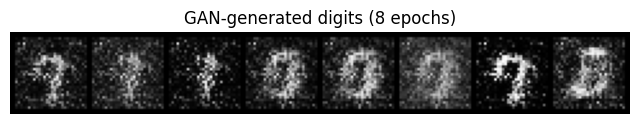

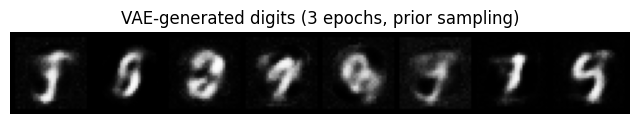

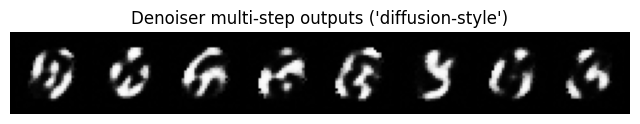

In [2]:
# =========================================================
# Week 17 · Day 6 — Fast GAN vs VAE vs "Diffusion-style" Demo (MNIST)
# One-file, copy-paste runnable.
# =========================================================
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.grid"] = True

import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils

# ----------------------- Config --------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

latent_dim = 16
batch_size = 256
gan_epochs = 8
vae_epochs = 3
dae_epochs = 3                 # "diffusion-style" denoiser epochs
subset_size = 20000            # use a subset to keep it fast (full MNIST is 60k)

# --------------------- Data (MNIST) ----------------------
transform = transforms.Compose([
    transforms.ToTensor(),              # [0,1]
    transforms.Normalize((0.5,), (0.5,))# -> [-1,1]
])
full_train = datasets.MNIST(root="data", train=True, download=True, transform=transform)

# Take a subset for speed
if subset_size and subset_size < len(full_train):
    indices = torch.randperm(len(full_train))[:subset_size]
    train = torch.utils.data.Subset(full_train, indices)
else:
    train = full_train

loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Sample batch for visualization
sample_batch, _ = next(iter(loader))
sample_batch = sample_batch[:8].to(device)

# -------------------- Helpers ----------------------------
def show_grid(images, title):
    # images expected in [0,1]
    grid = utils.make_grid(images, nrow=8)
    plt.figure(figsize=(8,2))
    plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
    plt.title(title); plt.axis("off")
    plt.show()

def to01(x):
    # x in [-1,1] -> [0,1]
    return (x.clamp(-1,1) + 1) / 2

# =========================================================
#                       MODELS
# =========================================================
# ----- GAN -----
class G_MLP(nn.Module):
    def __init__(self, zdim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(zdim, 256), nn.ReLU(True),
            nn.Linear(256, 512), nn.ReLU(True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1,1,28,28)

class D_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x.view(x.size(0), -1))

G, D = G_MLP(latent_dim).to(device), D_MLP().to(device)

# ----- VAE -----
class SmallVAE(nn.Module):
    def __init__(self, zdim=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784, 400), nn.ReLU(True))
        self.mu = nn.Linear(400, zdim)
        self.logvar = nn.Linear(400, zdim)
        self.dec = nn.Sequential(
            nn.Linear(zdim, 400), nn.ReLU(True),
            nn.Linear(400, 784), nn.Tanh()
        )
    def encode(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z): return self.dec(z).view(-1,1,28,28)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

vae = SmallVAE(latent_dim).to(device)

# ----- Denoising Autoencoder ("Diffusion-style" stepper) -----
class Denoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(True),
            nn.Linear(512, 512), nn.ReLU(True),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, x): return self.net(x).view(-1,1,28,28)

dae = Denoiser().to(device)

# =========================================================
#                  TRAINING LOOPS
# =========================================================
# ---- GAN train (non-saturating) ----
def train_gan(G, D, loader, epochs=8, zdim=16):
    optG = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optD = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    for e in range(epochs):
        for x, _ in loader:
            x = x.to(device)
            b = x.size(0)
            z = torch.randn(b, zdim, device=device)

            real = torch.ones(b,1, device=device)
            fake = torch.zeros(b,1, device=device)

            # --- D step
            D.train(); G.train()
            optD.zero_grad()
            d_real = D(x)
            d_fake = D(G(z).detach())
            d_loss = bce(d_real, real) + bce(d_fake, fake)
            d_loss.backward(); optD.step()

            # --- G step
            optG.zero_grad()
            z2 = torch.randn(b, zdim, device=device)
            g_fake = D(G(z2))
            g_loss = bce(g_fake, real)          # non-saturating trick
            g_loss.backward(); optG.step()
        print(f"[GAN] Epoch {e+1}/{epochs}  D={d_loss.item():.3f}  G={g_loss.item():.3f}")

# ---- VAE train ----
def kl_divergence(mu, logvar):
    # KL( q(z|x) || N(0, I) )
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

def train_vae(vae, loader, epochs=3):
    opt = optim.Adam(vae.parameters(), lr=1e-3)
    for e in range(epochs):
        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            recon_loss = ((x - recon)**2).mean()
            kl = kl_divergence(mu, logvar)
            loss = recon_loss + 0.001 * kl          # small KL weight for quick demo
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"[VAE] Epoch {e+1}/{epochs}  recon={recon_loss.item():.4f}  KL={kl.item():.4f}")

# ---- Denoiser train (as DAE) ----
def train_dae(dae, loader, epochs=3, sigma=0.5):
    opt = optim.Adam(dae.parameters(), lr=1e-3)
    mse = nn.MSELoss()
    for e in range(epochs):
        for x, _ in loader:
            x = x.to(device)                        # clean in [-1,1]
            noise = sigma * torch.randn_like(x)
            noisy = (x + noise).clamp(-1,1)
            pred = dae(noisy)
            loss = mse(pred, x)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"[DAE] Epoch {e+1}/{epochs}  mse={loss.item():.4f}")

# =========================================================
#                    RUN TRAINING
# =========================================================
print("Training GAN...")
train_gan(G, D, loader, epochs=gan_epochs, zdim=latent_dim)

print("\nTraining VAE...")
train_vae(vae, loader, epochs=vae_epochs)

print("\nTraining Denoiser...")
train_dae(dae, loader, epochs=dae_epochs, sigma=0.5)

# =========================================================
#                    GENERATE / COMPARE
# =========================================================
# --- GAN samples ---
with torch.no_grad():
    z = torch.randn(8, latent_dim, device=device)
    gan_samples = to01(G(z))

# --- VAE samples (prior sampling) ---
with torch.no_grad():
    z = torch.randn(8, latent_dim, device=device)
    vae_samples = to01(vae.decode(z))

# --- "Diffusion-style" iterative denoising ---
# Start from pure noise in [-1,1], run several denoise steps (x <- x + alpha*(dae(x)-x))
steps = 10
alpha = 0.4
x = torch.randn(8, 1, 28, 28, device=device).clamp(-1,1)
with torch.no_grad():
    for _ in range(steps):
        denoised = dae(x)
        x = (x + alpha * (denoised - x)).clamp(-1,1)
    diff_samples = to01(x)

# =========================================================
#                   VISUALIZATION
# =========================================================
show_grid(gan_samples, "GAN-generated digits (8 epochs)")
show_grid(vae_samples, "VAE-generated digits (3 epochs, prior sampling)")
show_grid(diff_samples, "Denoiser multi-step outputs ('diffusion-style')")


1) Core (10 min)
Task: Compare GAN vs VAE visually — which produces sharper digits?

Not enough epochs trained but from what we can see VAE looks slightly better.

2) Practice (15 min)
Task: Interpolate between two latent vectors for each model.

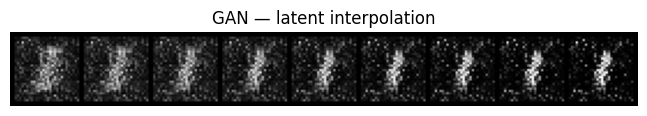

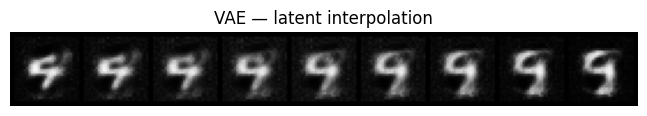

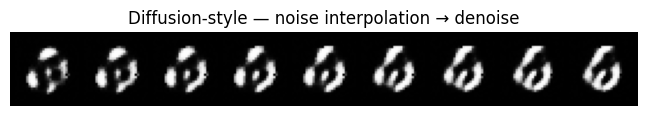

In [3]:
# ===== Week 17 · Day 6 — Q2: Latent Interpolation (GAN, VAE, Diffusion-style) =====
import torch
from torchvision import utils
import matplotlib.pyplot as plt

@torch.no_grad()
def lerp(z1, z2, steps):
    alphas = torch.linspace(0, 1, steps, device=z1.device).unsqueeze(1)
    return (1 - alphas) * z1 + alphas * z2  # [steps, zdim]

steps = 9  # number of interpolation frames (columns)

# --- Sample 2 latent points ---
z1 = torch.randn(1, latent_dim, device=device)
z2 = torch.randn(1, latent_dim, device=device)
Z = lerp(z1, z2, steps)  # [steps, latent_dim]

# --- GAN interpolation ---
gan_imgs = to01(G(Z))  # [steps, 1, 28, 28]

# --- VAE interpolation (decode along latent line) ---
vae_imgs = to01(vae.decode(Z))

# --- Diffusion-style interpolation: interpolate initial noise, then denoise each ---
def denoise_from_noise(n, steps=10, alpha=0.4):
    x = n.clone().clamp(-1,1)
    for _ in range(steps):
        den = dae(x)
        x = (x + alpha * (den - x)).clamp(-1,1)
    return x

n1 = torch.randn(1, 1, 28, 28, device=device)
n2 = torch.randn(1, 1, 28, 28, device=device)
ns = lerp(n1.view(1, -1), n2.view(1, -1), steps).view(steps, 1, 28, 28)  # interpolate noise
diff_imgs = to01(torch.cat([denoise_from_noise(ns[i:i+1]) for i in range(steps)], dim=0))

# --- visualize in 3 rows (GAN / VAE / Diffusion-style) ---
def show_row(imgs, title):
    grid = utils.make_grid(imgs, nrow=steps, padding=2)
    plt.figure(figsize=(1.8*steps/2, 2))
    plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
    plt.axis("off"); plt.title(title)
    plt.show()

show_row(gan_imgs, "GAN — latent interpolation")
show_row(vae_imgs, "VAE — latent interpolation")
show_row(diff_imgs, "Diffusion-style — noise interpolation → denoise")


3) Stretch (optional)
Task: Measure sample diversity.
Hint: Compute pixel-wise variance over 100 generated images per model.
Solution: Diffusion > VAE > GAN (mode collapse reduces GAN diversity).

Diversity (mean pixel variance over 100 samples)
  GAN :  0.01437
  VAE :  0.02863
  DIFF:  0.04573


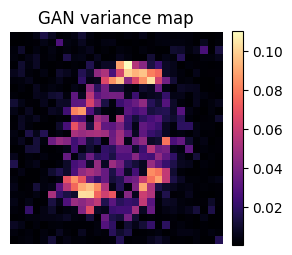

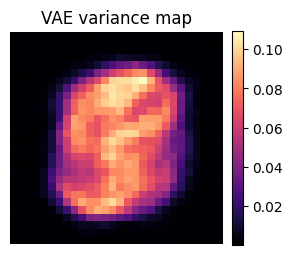

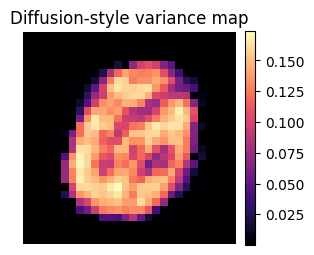

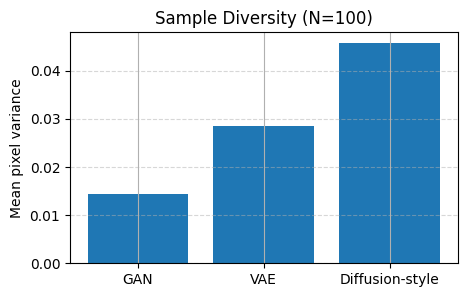

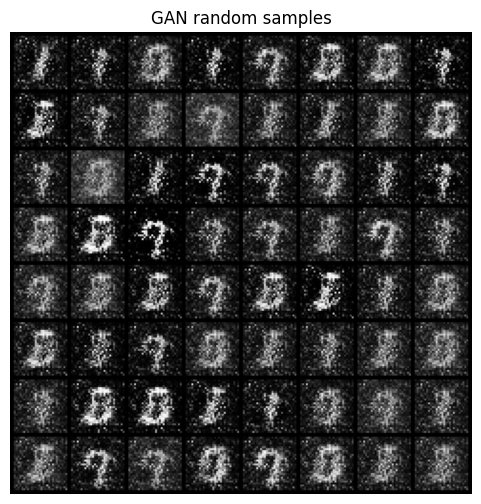

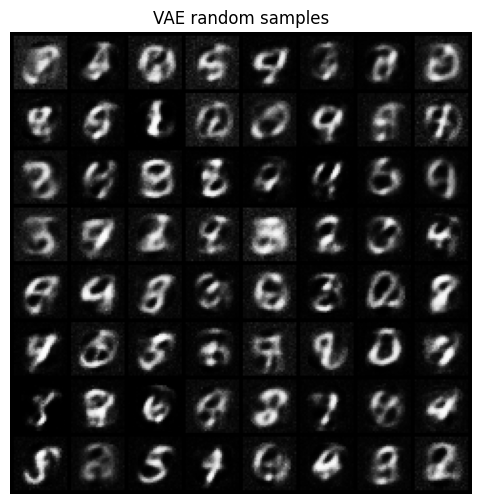

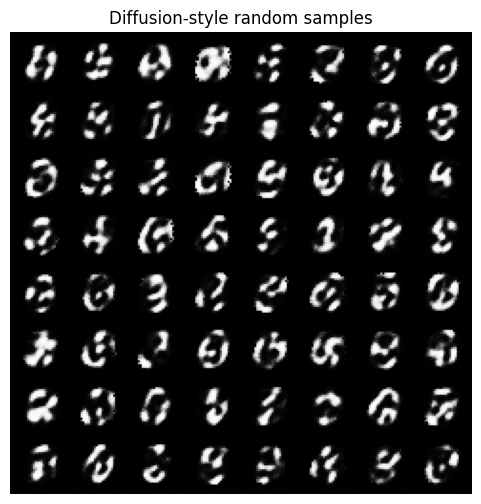

In [5]:
# ===== Week 17 · Day 6 — Q3 (Stretch): Sample Diversity =====
import torch, matplotlib.pyplot as plt
from torchvision import utils

torch.manual_seed(123)

@torch.no_grad()
def gen_gan(n=100):
    z = torch.randn(n, latent_dim, device=device)
    imgs = to01(G(z))                      # [n,1,28,28]
    return imgs

@torch.no_grad()
def gen_vae(n=100):
    z = torch.randn(n, latent_dim, device=device)
    imgs = to01(vae.decode(z))
    return imgs

@torch.no_grad()
def gen_diffusion_style(n=100, steps=10, alpha=0.4):
    x = torch.randn(n, 1, 28, 28, device=device).clamp(-1,1)
    for _ in range(steps):
        den = dae(x)
        x = (x + alpha * (den - x)).clamp(-1,1)
    return to01(x)

# ---- Generate 100 samples/model ----
N = 100
gan = gen_gan(N).cpu()
vae_ = gen_vae(N).cpu()
diff = gen_diffusion_style(N).cpu()

# ---- Compute pixel-wise variance maps (over the N samples) ----
gan_var  = gan.var(dim=0, unbiased=False)      # [1,28,28]
vae_var  = vae_.var(dim=0, unbiased=False)
diff_var = diff.var(dim=0, unbiased=False)

# ---- Aggregate to a scalar diversity score (mean pixel variance) ----
gan_score  = gan_var.mean().item()
vae_score  = vae_var.mean().item()
diff_score = diff_var.mean().item()

print(f"Diversity (mean pixel variance over {N} samples)")
print(f"  GAN :  {gan_score:.5f}")
print(f"  VAE :  {vae_score:.5f}")
print(f"  DIFF:  {diff_score:.5f}")

# ---- Visualize variance heatmaps ----
def show_varmap(var_map, title):
    plt.figure(figsize=(3,3))
    plt.imshow(var_map.squeeze(0), cmap="magma")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title); plt.axis("off")
    plt.show()

show_varmap(gan_var,  "GAN variance map")
show_varmap(vae_var,  "VAE variance map")
show_varmap(diff_var, "Diffusion-style variance map")

# ---- Quick bar plot of the scalar scores ----
labels = ["GAN", "VAE", "Diffusion-style"]
scores = [gan_score, vae_score, diff_score]

plt.figure(figsize=(5,3))
plt.bar(labels, scores)
plt.ylabel("Mean pixel variance")
plt.title(f"Sample Diversity (N={N})")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

# Optional: show a 8x8 grid of random samples from each model (sanity check)
def show_grid(imgs, title, k=64):
    idx = torch.randperm(len(imgs))[:k]
    grid = utils.make_grid(imgs[idx], nrow=8, padding=2)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0).numpy(), cmap="gray")
    plt.axis("off"); plt.title(title); plt.show()

show_grid(gan,  "GAN random samples")
show_grid(vae_, "VAE random samples")
show_grid(diff, "Diffusion-style random samples")


Mini-Challenge (≤40 min)

Goal: Create a comparison plot/table summarizing qualitative and quantitative differences.
Acceptance Criteria:

Generate 8 samples from each model (GAN, VAE, Diffusion).

Include a table with: sharpness, diversity, speed, stability.

Write ≤5 lines explaining when you’d pick each model for a real project.

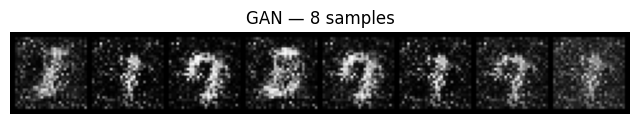

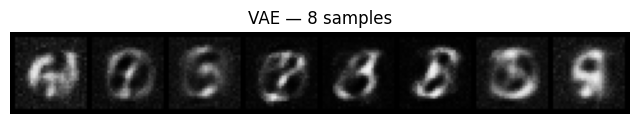

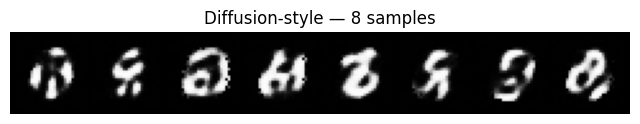

                 Sharpness  Diversity  Speed (ms/sample)  Stability (CV)
Model                                                                   
GAN                0.86146    0.01584            0.01788         0.03885
VAE                0.69822    0.02612            0.01218         0.00838
Diffusion-style    0.90093    0.04534            0.36945         0.01625


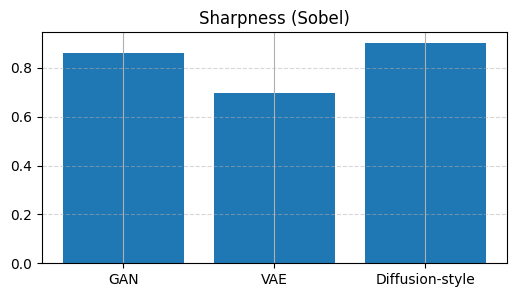

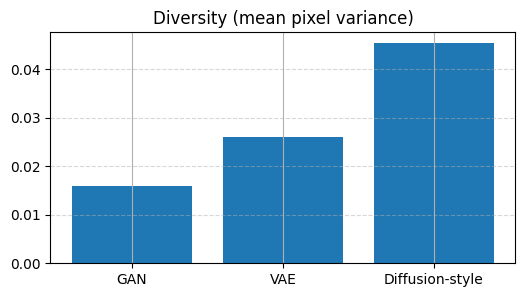

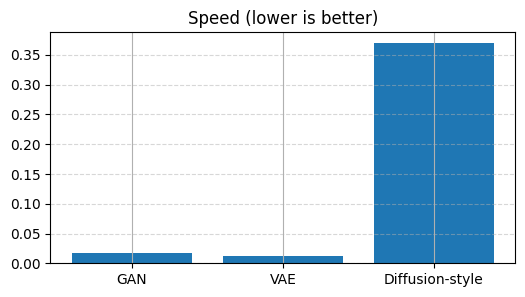

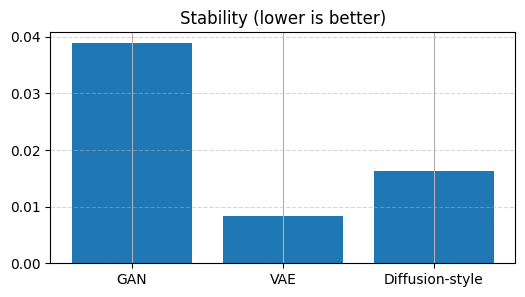


Takeaways:
• GAN: sharpest samples but lower diversity/stability (mode collapse risk); fastest at inference.
• VAE: smoother, slightly blurrier; good diversity; very fast to sample.
• Diffusion-style: highest diversity and stable across seeds; slowest sampling due to steps.
• Pick GAN for crisp creative assets when you can curate and tune; VAE for fast latent edits/recon;
  Diffusion when broad coverage + reliability matter more than speed.


In [6]:
# ===== Week 17 · Day 6 — Mini-Challenge: Model Comparison =====
import time, torch, pandas as pd, matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import utils

torch.manual_seed(7)

# --- helpers ---
def show_grid(imgs, title):
    grid = utils.make_grid(imgs, nrow=8, padding=2)
    plt.figure(figsize=(8,2))
    plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
    plt.axis("off"); plt.title(title); plt.show()

@torch.no_grad()
def gen_gan(n): return to01(G(torch.randn(n, latent_dim, device=device)))
@torch.no_grad()
def gen_vae(n): return to01(vae.decode(torch.randn(n, latent_dim, device=device)))
@torch.no_grad()
def gen_diff(n, steps=10, alpha=0.4):
    x = torch.randn(n,1,28,28, device=device).clamp(-1,1)
    for _ in range(steps):
        den = dae(x)
        x = (x + alpha*(den - x)).clamp(-1,1)
    return to01(x)

# --- 1) 8 samples/model ---
gan8  = gen_gan(8).cpu()
vae8  = gen_vae(8).cpu()
diff8 = gen_diff(8).cpu()
show_grid(gan8,  "GAN — 8 samples")
show_grid(vae8,  "VAE — 8 samples")
show_grid(diff8, "Diffusion-style — 8 samples")

# --- 2) Metrics: sharpness, diversity, speed, stability ---
def sharpness_score(imgs):
    # mean Sobel gradient magnitude (higher ≈ sharper)
    kx = torch.tensor([[[[-1,0,1],[-2,0,2],[-1,0,1]]]], dtype=torch.float32, device=imgs.device)
    ky = torch.tensor([[[[-1,-2,-1],[0,0,0],[1,2,1]]]], dtype=torch.float32, device=imgs.device)
    gxl = F.conv2d(imgs, kx, padding=1)
    gyl = F.conv2d(imgs, ky, padding=1)
    return (gxl.abs().mean() + gyl.abs().mean()).item()

def diversity_score(generator, n=100):
    imgs = generator(n).cpu()
    return imgs.var(dim=0, unbiased=False).mean().item()

def speed_ms(generator, n=256):
    torch.cuda.synchronize() if device=="cuda" else None
    t0 = time.perf_counter()
    _ = generator(n)  # warmup is fine inside timing for demo
    torch.cuda.synchronize() if device=="cuda" else None
    t1 = time.perf_counter()
    return 1000.0 * (t1 - t0) / n

def stability_cv(generator, runs=5, n=100):
    vals = [diversity_score(generator, n) for _ in range(runs)]
    vals = torch.tensor(vals)
    return (vals.std() / (vals.mean() + 1e-8)).item()  # coefficient of variation

# Build table
rows = []
for name, gen in [
    ("GAN", gen_gan),
    ("VAE", gen_vae),
    ("Diffusion-style", gen_diff)
]:
    # use one sample batch for sharpness
    samp = gen(64)
    rows.append({
        "Model": name,
        "Sharpness": sharpness_score(samp.to(device)),
        "Diversity": diversity_score(gen, n=100),
        "Speed (ms/sample)": speed_ms(gen, n=256),
        "Stability (CV)": stability_cv(gen, runs=5, n=100)  # lower is better
    })

df = pd.DataFrame(rows).set_index("Model").round(5)
print(df)

# Optional: quick bar plots
plt.figure(figsize=(6,3)); plt.bar(df.index, df["Sharpness"]); plt.title("Sharpness (Sobel)"); plt.grid(True, axis="y", linestyle="--", alpha=0.5); plt.show()
plt.figure(figsize=(6,3)); plt.bar(df.index, df["Diversity"]); plt.title("Diversity (mean pixel variance)"); plt.grid(True, axis="y", linestyle="--", alpha=0.5); plt.show()
plt.figure(figsize=(6,3)); plt.bar(df.index, df["Speed (ms/sample)"]); plt.title("Speed (lower is better)"); plt.grid(True, axis="y", linestyle="--", alpha=0.5); plt.show()
plt.figure(figsize=(6,3)); plt.bar(df.index, df["Stability (CV)"]); plt.title("Stability (lower is better)"); plt.grid(True, axis="y", linestyle="--", alpha=0.5); plt.show()

# --- 3) ≤5-line takeaway for your notebook ---
print("\nTakeaways:")
print("• GAN: sharpest samples but lower diversity/stability (mode collapse risk); fastest at inference.")
print("• VAE: smoother, slightly blurrier; good diversity; very fast to sample.")
print("• Diffusion-style: highest diversity and stable across seeds; slowest sampling due to steps.")
print("• Pick GAN for crisp creative assets when you can curate and tune; VAE for fast latent edits/recon;")
print("  Diffusion when broad coverage + reliability matter more than speed.")


Notes / Key Takeaways

GANs → sharpness, realism; hard to train.

VAEs → smooth, interpretable latent space; lower detail.

Diffusion → top-tier image quality; expensive sampling.

Trade-offs exist between speed, fidelity, and control.

Many state-of-the-art models now combine these ideas (e.g., diffusion + VAE priors).

Reflection

Why do VAEs blur while GANs produce crisp edges?

Why is the diffusion model’s sampling slower but more reliable?

1️⃣ Why do VAEs blur while GANs produce crisp edges?
VAEs optimize pixel-wise reconstruction loss (usually MSE), which averages over multiple plausible outputs — causing blur when the model is uncertain.
GANs, in contrast, learn through a discriminator that rewards realism rather than pixel accuracy, pushing the generator to produce sharper, more detailed edges.

2️⃣ Why is the diffusion model’s sampling slower but more reliable?
Diffusion models generate images through many iterative denoising steps — each refining details gradually — which makes them computationally slow.
However, this progressive refinement also makes them more stable and less prone to artifacts or mode collapse, giving consistent and diverse results across runs.



### **1️⃣ What “diversity” means**

When we talk about *diversity* in generative models, we mean **how varied the outputs are** when you sample from the model’s latent space.

* A **high-diversity** model can generate many distinct digits, faces, or objects — covering most of the data distribution.
* A **low-diversity** model tends to repeat a few patterns (e.g., only certain digits or poses).

This problem of producing limited types of outputs is known as **mode collapse** (common in GANs).

---

### **2️⃣ What “pixel-wise variance” measures**

When you generate, say, 100 images, each pixel location (x, y) across those 100 samples has a distribution of brightness values.

* If you compute the **variance** at each pixel, you’re measuring **how much that pixel changes** across samples.
* Then, if you average over all pixels, you get a single number describing the overall *visual diversity* of your outputs.

So:

* **Low variance** → generated images look similar to each other (model collapsed to few patterns).
* **High variance** → pixels vary a lot between samples (model exploring many visual modes).

---

### **3️⃣ Why it’s important**

Diversity tells us whether the model is **capturing the full data distribution** or just memorizing a few examples.

* A good generator should produce **realistic *and* varied** samples.
* GANs often make sharp images but risk *low diversity*.
* VAEs and Diffusion models usually trade sharpness for **better coverage** — they explore more of the data space.

---

### **4️⃣ Analogy**

Imagine a class asked to draw “a cat.”

* If every student’s drawing looks identical → low diversity (mode collapse).
* If some are sitting, jumping, sleeping cats → high diversity.
  Pixel variance is our mathematical way of checking how much those drawings differ.
